<a href="https://colab.research.google.com/github/chizkidd/transformers-from-scratch/blob/main/attention-is-all-you-need.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transformer Models: A collection of various transformer architectures, models, & their implementations (`PyTorch`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/transformers-from-scratch

In [1]:
%%capture
!pip install watermark
!pip install torchinfo
!pip install sacrebleu

In [2]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 7.34.0

torch: 2.10.0+cu128



# Attention is All You Need
---

The network in this notebook is a foundational implementation of the **Transformer** architecture **[1]** on the **Multi30k** (a standard English-to-German translation dataset) dataset. This marks the definitive transition from **Recurrence** (processing sequences step-by-step) to **Parallelism** (processing the entire sequence at once). This architecture is the "Big Bang" of modern Large Language Models (LLMs) and the foundational engine for GPT, BERT, and Gemini.

<br>

## **Network Architecture:**

The Transformer discards RNNs and LSTMs entirely, operating on the **Self-Attention** principle through two distinct stacks:

1.  **The Encoder:** A stack of $N$ identical layers. Each layer has two sub-layers: a **Multi-Head Self-Attention** mechanism and a simple, position-wise **Feed-Forward Network**. It creates a high-dimensional representation where every word "looks" at every other word in the sentence simultaneously.
2.  **The Decoder:** Also a stack of $N$ identical layers. In addition to the two sub-layers in the encoder, the decoder inserts a third sub-layer, which performs **Multi-Head Attention** over the output of the encoder stack. It uses "Masking" to ensure that the prediction for a word can only depend on the known outputs at positions before it.

<br><br>

### **The Core Architecture: Attention**
---
This is the engine of the Transformer. Instead of sequential hidden states, we compute attention across all tokens simultaneously using the scaled dot-product formula:

$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

<br><br>

### **Multi-Head Attention (MHA)**

The Multi-Head Attention mechanism allows the model to jointly attend to information from different representation subspaces at different positions. This is defined as:

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)W^O$$

Where each head is computed using the **Scaled Dot-Product Attention**:

$$\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V) = \text{softmax}\left(\frac{(QW_i^Q)(KW_i^K)^T}{\sqrt{d_k}}\right)(VW_i^V)$$

**Where the projections are parameter matrices:**
* $W_i^Q \in \mathbb{R}^{d_{model} \times d_k}$
* $W_i^K \in \mathbb{R}^{d_{model} \times d_k}$
* $W_i^V \in \mathbb{R}^{d_{model} \times d_v}$
* $W^O \in \mathbb{R}^{hd_v \times d_{model}}$

In the original paper, $h = 8$ heads and $d_k = d_v = d_{model} / h = 64$.

---

#### **Transformer**

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*f3L_gGaNy9wVuTenyQJLEA.png)

([Source](https://arxiv.org/pdf/1706.03762))<br><br>

---

#### **Attention**

![](https://machinelearningmastery.com/wp-content/uploads/2022/03/dotproduct_1-1536x825.png)

([Source](https://arxiv.org/pdf/1706.03762))<br><br>


-----

## **Key Concepts of the `Attention Is All You Need` Architecture:**

1.  **Scaled Dot-Product Attention:** The mathematical core. It computes a compatibility score between a **Query** and a **Key**, which is then used to weight a **Value**. We scale by $\sqrt{d_k}$ to prevent gradients from vanishing during softmax.
2.  **Multi-Head Attention:** Instead of performing a single attention function, we project the queries, keys, and values $h$ times. This allows the model to jointly attend to information from different representation subspaces at different positions.
3.  **Positional Encoding:** Since there is no recurrence, the model has no inherent sense of word order. We inject "positional encodings" (sine and cosine functions) into the input embeddings to provide information about the relative or absolute position of the tokens.
4.  **The Residual Connection:** Every sub-layer (Attention and FFN) is surrounded by a residual connection followed by **Layer Normalization**. This ensures that deep gradients can flow easily during training.
5.  **Parallelization:** Unlike LSTMs, which require $O(n)$ sequential steps, the Transformer performs most of its heavy lifting in $O(1)$ parallel steps, making it significantly faster to train on modern GPUs.

<br><br>

-----

## **Quick Comparison: Recurrent Seq2Seq vs. Parallel Transformer**

| Feature | Recurrent Seq2Seq (LSTM/GRU) | Transformer (Self-Attention) |
| :--- | :--- | :--- |
| **Processing Style** | Sequential (Step-by-Step) | **Parallel (Whole Sequence)** |
| **Path Length** | $O(n)$ to link distant words | **$O(1)$ to link any two words** |
| **Memory Component** | Hidden State ($h_t$) | **Attention Weights** |
| **Inductive Bias** | Temporal Order / Recurrence | **Relational / Global Context** |
| **Sequence Length Limit** | High (due to "Vanishing Gradient") | **Low (due to $O(n^2)$ complexity)** |
| **Word Order** | Inherent in the loop | **Explicit (Positional Encoding)** |
| **Primary Metric** | Perplexity (PPL) | **BLEU Score** |

<br><br>

## **Detailed Tabular Audit Summary**

---
| Tier | PPL | BPC | BLEU | Core Behavioral Signature |
| :--- | :---: | :---: | :---: | :--- |
| **Random** | 500+ | 8.0+ | 0-2 | Gibberish; lacks basic SOS/EOS structure. |
| **Structuralist** | 100-300 | 6.5-8 | 3-8 | Basic syntax emerges; high noun hallucinations. |
| **Generalist (`Seq2Seq`)** | 40-80 | 5-6.5 | 9-15 | Frequency bias; sequence bottleneck degrades long inputs. |
| **Robust (`Transformer`)** | **< 20** | **< 3.5** | **25-35** | **Highly parallelized; precise long-range token alignment.** |
| **SOTA (LLMs)** | < 10 | < 2.0 | 40+ | Zero-shot contextual reasoning and nuance. |

<br><br>

-----

**REFERENCES:**

1.  Vaswani, Ashish, et al. ["Attention is all you need."](https://arxiv.org/abs/1706.03762) *Advances in neural information processing systems*, 2017. **(The "Transformer" Origin)**
2.  Alammar, Jay. ["The Illustrated Transformer."](https://jalammar.github.io/illustrated-transformer/) *Jay Alammar's Blog*, 2018. **(Visualizing the Parallel Era)**
3.  Harvard NLP. ["The Annotated Transformer."](https://nlp.seas.harvard.edu/annotated-transformer/) *Open Source Implementation V2*, 2022. **(Code-First Deep Dive)**
4.  Zhang, Aston, et al. ["The Transformer Architecture."](https://d2l.ai/chapter_attention-mechanisms-and-transformers/transformer.html) *Dive into Deep Learning*, Ch. 11.7. **(Mathematical Formalization)**
5.  Elliott, Desmond, et al. ["Multi30k: Multilingual Extended Descriptional Images."](https://aclanthology.org/W16-3210) *Proc. 5th Workshop on Vision and Language*, 2016. **(Core Dataset Source)**
6.  Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI

-----



In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Sampler, DataLoader
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset, DatasetDict
from collections import Counter

import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import sacrebleu

# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random
import re

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [4]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [5]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
NUM_EPOCHS = 50

# Vocabulary & Architecture
VOCABULARY_SIZE = 5000
BATCH_SIZE = 128

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


---
# 1. Data Preparation & Loading

---

In [6]:
# 1. Load Dataset
DATASET_CONFIG = "bentrevett/multi30k"
raw_datasets = load_dataset(DATASET_CONFIG)

# 2. Vocabulary Logic
# Included basic punctuation in the tokenizer for better translation nuance
def tokenizer(text):
    return re.findall(r"[\w']+|[.,!?;]", text.lower())

en_counts, de_counts = Counter(), Counter()
for item in raw_datasets['train']:
    en_counts.update(tokenizer(item['en']))
    de_counts.update(tokenizer(item['de']))

SPECIAL_TOKENS = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
def build_vocab(counts, max_size):
    vocab = {word: i for i, word in enumerate(SPECIAL_TOKENS)}
    for word, _ in counts.most_common(max_size - len(SPECIAL_TOKENS)):
        if word not in vocab:
            vocab[word] = len(vocab)
    return vocab

src_vocab = build_vocab(en_counts, VOCABULARY_SIZE)
trg_vocab = build_vocab(de_counts, VOCABULARY_SIZE)

SRC_PAD_IDX = src_vocab['<PAD>']
TRG_PAD_IDX = trg_vocab['<PAD>']

print(f"Source (EN) Vocab size: {len(src_vocab)}")
print(f"Target (DE) Vocab size: {len(trg_vocab)}")


# 3. Transformer-Ready Collate Batch
def collate_batch(batch):
    src_list, trg_list = [], []

    for item in batch:
        # Source: No reversal needed for Transformers!
        src_toks = [src_vocab['<SOS>']] + \
                   [src_vocab.get(t, src_vocab['<UNK>']) for t in tokenizer(item['en'])] + \
                   [src_vocab['<EOS>']]

        # Target: Standard sequence
        trg_toks = [trg_vocab['<SOS>']] + \
                   [trg_vocab.get(t, trg_vocab['<UNK>']) for t in tokenizer(item['de'])] + \
                   [trg_vocab['<EOS>']]

        src_list.append(torch.tensor(src_toks, dtype=torch.int64))
        trg_list.append(torch.tensor(trg_toks, dtype=torch.int64))

    # Pad sequences - Transformer expects (Batch, Seq_Len)
    src_padded = pad_sequence(src_list, batch_first=True, padding_value=SRC_PAD_IDX)
    trg_padded = pad_sequence(trg_list, batch_first=True, padding_value=TRG_PAD_IDX)

    return src_padded, trg_padded

# 4. Initialize DataLoaders
train_loader = DataLoader(raw_datasets['train'], shuffle=True, batch_size=BATCH_SIZE, collate_fn=collate_batch)
val_loader   = DataLoader(raw_datasets['validation'], shuffle=False, batch_size=BATCH_SIZE, collate_fn=collate_batch)
test_loader   = DataLoader(raw_datasets['test'], shuffle=False, batch_size=BATCH_SIZE, collate_fn=collate_batch)

README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Source (EN) Vocab size: 5000
Target (DE) Vocab size: 5000


---
# 2. Model Creation

---


In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1, device=DEVICE):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc_out = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([self.d_k])).to(device)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        # Linear transformations and split into heads
        Q = self.w_q(query).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(key).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(value).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # Scaled Dot-Product Attention
        energy = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            energy = energy.masked_fill(mask == 0, float('-inf')) #-1e10)

        attention = torch.softmax(energy, dim=-1)
        x = torch.matmul(self.dropout(attention), V)

        # Concatenate heads and project
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.fc_out(x)

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(torch.relu(self.fc1(x))))

In [9]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        # 1. Self-Attention + Residual + Norm
        _src = self.self_attn(src, src, src, src_mask)
        src = self.norm1(src + self.dropout(_src))

        # 2. Feed-Forward + Residual + Norm
        _src = self.feed_forward(src)
        src = self.norm2(src + self.dropout(_src))
        return src


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, trg, enc_src, trg_mask, src_mask):
        # 1. Masked Self-Attention
        _trg = self.self_attn(trg, trg, trg, trg_mask)
        trg = self.norm1(trg + self.dropout(_trg))

        # 2. Cross-Attention (Encoder-Decoder)
        # Query comes from Decoder (trg), Key/Value come from Encoder (enc_src)
        _trg = self.cross_attn(trg, enc_src, enc_src, src_mask)
        trg = self.norm2(trg + self.dropout(_trg))

        # 3. Feed-Forward
        _trg = self.feed_forward(trg)
        trg = self.norm3(trg + self.dropout(_trg))
        return trg

In [10]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        x = self.dropout(self.pos_encoding(self.embedding(src)))
        for layer in self.layers:
            x = layer(x, src_mask)
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, trg, enc_src, trg_mask, src_mask):
        x = self.dropout(self.pos_encoding(self.embedding(trg)))
        for layer in self.layers:
            x = layer(x, enc_src, trg_mask, src_mask)
        return self.fc_out(x)

In [11]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, src_pad_idx, trg_pad_idx,
                 d_model=512, n_layers=6, n_heads=8, d_ff=2048, dropout=0.1, max_len=100, device=DEVICE):
        super().__init__()
        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.d_model = d_model  # FIX 4: store for embedding scaling

        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(trg_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

        self.fc_out = nn.Linear(d_model, trg_vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.device = device

    def make_src_mask(self, src):
        return (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)

    def make_trg_mask(self, trg):
        trg_pad_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2)
        trg_len = trg.shape[1]
        trg_sub_mask = torch.tril(torch.ones((trg_len, trg_len), device=self.device)).bool()
        return trg_pad_mask & trg_sub_mask

    def forward(self, src, trg):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)

        # FIX 4: Scale embeddings by sqrt(d_model) per Section 3.4 of the paper.
        # Without this, positional encodings dominate the embedding signal.
        scale = math.sqrt(self.d_model)

        enc_src = self.positional_encoding(self.encoder_embedding(src) * scale)
        for layer in self.encoder_layers:
            enc_src = layer(enc_src, src_mask)

        dec_trg = self.positional_encoding(self.decoder_embedding(trg) * scale)
        for layer in self.decoder_layers:
            dec_trg = layer(dec_trg, enc_src, trg_mask, src_mask)

        return self.fc_out(dec_trg)


In [12]:
def count_parameters_transformer(model):
    """
    Robust parameter counter for the 'Attention Is All You Need' architecture.
    Breakdown focused on the shift from Recurrence to Parallel Attention stacks.
    """
    def count(m):
      return sum(p.numel() for p in m.parameters() if p.requires_grad)

    # 1. Embeddings (Shared across tokens)
    enc_emb = count(model.encoder_embedding)
    dec_emb = count(model.decoder_embedding)

    # 2. The Transformer Stacks (The core 'Parallel' engine)
    # Includes all MHA blocks, LayerNorms, and Feed-Forward Networks
    enc_total = count(model.encoder_layers)
    dec_total = count(model.decoder_layers)

    # 3. Final Prediction Head
    output_proj = count(model.fc_out)

    total_params = count(model)

    print(f"{'Component':<25} | {'Parameters':<12}")
    print("-" * 42)
    print(f"{'Encoder Embeddings':<25} | {enc_emb:,}")
    print(f"{'Encoder Stack (N Layers)':<25} | {enc_total:,}")
    print(f"{'Decoder Embeddings':<25} | {dec_emb:,}")
    print(f"{'Decoder Stack (N Layers)':<25} | {dec_total:,}")
    print(f"{'Output Projection':<25} | {output_proj:,}")
    print("-" * 42)
    print(f"{'TOTAL TRAINABLE':<25} | {total_params:,}")

---
# 3. Model Training, Testing & Evaluation

---

In [13]:
class LabelSmoothingLoss(nn.Module):
    def __init__(self, size, padding_idx, smoothing=0.1):
        super(LabelSmoothingLoss, self).__init__()
        self.criterion = nn.KLDivLoss(reduction='sum')
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        assert x.size(1) == self.size

        # FIX 1: KLDivLoss expects LOG-PROBABILITIES, not raw logits.
        # Without this, loss explodes to inf/NaN immediately.
        x = F.log_softmax(x, dim=-1)

        true_dist = x.data.clone()
        true_dist.fill_(self.smoothing / (self.size - 2))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        true_dist[:, self.padding_idx] = 0
        mask = torch.nonzero(target.data == self.padding_idx)
        if mask.dim() > 0:
            true_dist.index_fill_(0, mask.squeeze(), 0.0)
        self.true_dist = true_dist
        return self.criterion(x, true_dist.detach())


class NoamOpt:
    "Optim wrapper that implements the specific Transformer LR schedule."
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0

    def step(self):
        "Update LR schedule only. The actual optimizer.step() is handled by GradScaler."
        self._step += 1
        rate = self.rate()
        for p in self.optimizer.param_groups:
            p['lr'] = rate
        self._rate = rate
        # FIX 2: REMOVED self.optimizer.step() — it was causing a DOUBLE step
        # every iteration (once here, once via scaler.step). The second step
        # uses stale/zeroed gradients, corrupting weights toward NaN.

    def rate(self, step=None):
        "Implement `lrate` from the paper (with step=0 guard)."
        if step is None:
            step = self._step
        # FIX 2b: Guard against step=0 to prevent 0**(-0.5) -> inf -> NaN.
        # (Matches the Harvard Annotated Transformer reference implementation.)
        if step == 0:
            step = 1
        return self.factor * (
            self.model_size ** (-0.5) * min(step ** (-0.5), step * self.warmup ** (-1.5))
        )


In [14]:
def evaluate_transformer(model, data_loader, criterion, device):
    """
    Robust evaluation for the 'Attention Is All You Need' architecture.
    Uses parallel decoding with causal masking instead of sequential loops.
    """
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for src, trg in data_loader:
            src, trg = src.to(device), trg.to(device)

            trg_input = trg[:, :-1]
            trg_output = trg[:, 1:]

            output = model(src, trg_input)
            output_dim = output.shape[-1]

            output = output.contiguous().view(-1, output_dim)
            trg_output = trg_output.contiguous().view(-1)

            loss = criterion(output, trg_output)

            n_tokens = (trg_output != TRG_PAD_IDX).sum().item()

            # FIX 3: criterion uses reduction='sum', so loss.item() is already
            # the total loss for this batch. Do NOT multiply by n_tokens again.
            total_loss += loss.item()
            total_tokens += n_tokens

    avg_loss = total_loss / total_tokens
    ppl = math.exp(min(avg_loss, 100))  # Clamp to avoid overflow
    bpc = avg_loss / math.log(2)

    return avg_loss, ppl, bpc


In [15]:
def train_transformer(model, train_loader, val_loader, optimizer, criterion, num_epochs, device, patience=5):
    """
    Robust Transformer training loop with Mixed Precision and Noam Scheduling.
    """
    # FIX 7: Only use GradScaler/autocast when on CUDA
    use_amp = (device.type == 'cuda')
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    start_time = time.time()
    best_val_loss = float('inf')
    epochs_no_improve = 0

    history = {'train_loss': [], 'val_loss': [], 'val_ppl': [], 'val_bpc': [], 'lrs': []}

    print(f"Starting Transformer training on {device}...")

    for epoch in range(num_epochs):
        model.train()
        train_running_loss = 0.0
        train_tokens = 0

        for src, trg in train_loader:
            src, trg = src.to(device, non_blocking=True), trg.to(device, non_blocking=True)

            trg_input = trg[:, :-1]
            trg_output = trg[:, 1:]

            optimizer.optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda', enabled=use_amp):
                output = model(src, trg_input)
                output_dim = output.shape[-1]

                output = output.contiguous().view(-1, output_dim)
                trg_output = trg_output.contiguous().view(-1)

                loss = criterion(output, trg_output)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer.optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # FIX 2: scaler.step() does the actual Adam update.
            # optimizer.step() now ONLY updates the Noam LR schedule (no double step).
            scaler.step(optimizer.optimizer)
            scaler.update()
            optimizer.step()  # Updates LR only

            n_tokens = (trg_output != TRG_PAD_IDX).sum().item()
            train_running_loss += loss.item()
            train_tokens += n_tokens

        # --- Epoch Evaluation ---
        epoch_train_loss = train_running_loss / train_tokens
        epoch_val_loss, epoch_val_ppl, epoch_val_bpc = evaluate_transformer(model, val_loader, criterion, device)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), 'best_transformer.pth')
            epochs_no_improve = 0
            status_msg = " * (Saved Best)"
        else:
            epochs_no_improve += 1
            status_msg = f" (No improve: {epochs_no_improve}/{patience})"

        current_lr = optimizer._rate

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_ppl'].append(epoch_val_ppl)
        history['val_bpc'].append(epoch_val_bpc)
        history['lrs'].append(current_lr)
        elapsed = time.time() - start_time
        tok_per_sec = train_tokens / elapsed

        print(f'Epoch {epoch + 1:03d}/{num_epochs:03d} | '
              f'Loss (T/V): {epoch_train_loss:.4f} / {epoch_val_loss:.4f} | '
              f'PPL (V): {epoch_val_ppl:04.2f} | '
              f'BPC (V): {epoch_val_bpc:.4f} | '
              f'tokens/sec: {tok_per_sec:07.2f} | '
              f'LR: {current_lr:.6f}{status_msg}')

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered.")
            break

    print(f'\nDone! Total Time: {(time.time() - start_time) / 60:.2f} min')
    model.load_state_dict(torch.load('best_transformer.pth'))
    return history


In [16]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    # Identify which metrics were tracked
    has_acc = 'val_acc' in history
    has_f1  = 'val_f1' in history
    has_gen = 'val_ppl' in history

    # Dynamic grid layout
    num_plots = 2 + int(has_acc) + int(has_f1) + int(has_gen)
    plt.figure(figsize=(num_plots * 5, 5))

    # --- Plot 1: Loss ---
    plt.subplot(1, num_plots, 1)
    plt.plot(epochs, history['train_loss'], 'o-', label='Train ', color='#1f77b4')
    plt.plot(epochs, history['val_loss'], 's--', label='Val', color='#ff7f0e')
    plt.title('Cross Entropy Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plot_idx = 2

    # --- Plot 2: Accuracy ---
    if has_acc:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['train_acc']) * 100, 'o-', label='Train', color='#1f77b4')
        plt.plot(epochs, np.array(history['val_acc']) * 100, 's--', label='Val', color='#ff7f0e')
        plt.title('Accuracy (%)')
        plt.xlabel('Epochs')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 3: F1 Score ---
    if has_f1:
        plt.subplot(1, num_plots, plot_idx)
        plt.plot(epochs, np.array(history['val_f1']) * 100, 'd-', label='Val F1', color='#2ca02c')
        plt.title('F1 Score (%)')
        plt.ylabel('Percentage')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 4: Generative Metrics (PPL & BPC) ---
    if has_gen:
        plt.subplot(1, num_plots, plot_idx)
        ax1 = plt.gca()

        # PPL on Primary Y-Axis
        ax1.plot(epochs, history['val_ppl'], 'o-', label='PPL', color='purple')
        ax1.set_ylabel('Perplexity', color='purple', fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='purple')

        if 'val_bpc' in history:
            # BPC on Secondary Y-Axis
            ax2 = ax1.twinx()
            ax2.plot(epochs, history['val_bpc'], 'x--', label='BPC', color='red')
            ax2.set_ylabel('Bits Per Character (BPC)', color='red', fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='red')
            ax2.grid(False)

        plt.title('Generative Metrics')
        ax1.set_xlabel('Epochs')
        ax1.grid(True, alpha=0.3)
        plot_idx += 1

    # --- Plot 5: Learning Rate ---
    plt.subplot(1, num_plots, num_plots)
    plt.plot(epochs, history['lrs'], label='LR', color='black', linewidth=2)
    plt.title('LR Schedule')
    plt.xlabel('Epochs')
    plt.ylabel('Rate')
    plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [17]:
def plot_transformer_performance(history):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Loss Curve
    ax[0].plot(history['train_loss'], label='Train Loss', marker='o')
    ax[0].plot(history['val_loss'], label='Val Loss', marker='x')
    ax[0].set_title('Cross Entropy Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()

    # 2. Perplexity (PPL)
    ax[1].plot(history['val_ppl'], color='orange', label='Val PPL', marker='s')
    ax[1].set_title('Validation Perplexity')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()

    # 3. Noam Learning Rate Schedule
    # This proves your Warmup logic worked correctly
    ax[2].plot(history['lrs'], color='green', label='Learning Rate')
    ax[2].set_title('Noam Scheduler (Warmup)')
    ax[2].set_xlabel('Epoch')
    ax[2].legend()

    plt.tight_layout()
    plt.show()

---
# 4. Model Inference

---

In [18]:
def _translate_sentence(sentence, model, src_vocab, trg_vocab, device, max_len=50):
    model.eval()

    # Tokenize and numericalize
    tokens = tokenizer(sentence)
    tokens = [src_vocab['<SOS>']] + [src_vocab.get(t, src_vocab['<UNK>']) for t in tokens] + [src_vocab['<EOS>']]
    src_tensor = torch.LongTensor(tokens).unsqueeze(0).to(device)

    src_mask = model.make_src_mask(src_tensor)
    scale = math.sqrt(model.d_model)  # FIX 4: match forward() scaling

    with torch.no_grad():
        enc_src = model.encoder_embedding(src_tensor) * scale
        enc_src = model.positional_encoding(enc_src)
        for layer in model.encoder_layers:
            enc_src = layer(enc_src, src_mask)

    trg_indices = [trg_vocab['<SOS>']]

    for i in range(max_len):
        trg_tensor = torch.LongTensor(trg_indices).unsqueeze(0).to(device)
        trg_mask = model.make_trg_mask(trg_tensor)

        with torch.no_grad():
            output = model.decoder_embedding(trg_tensor) * scale
            output = model.positional_encoding(output)
            for layer in model.decoder_layers:
                output = layer(output, enc_src, trg_mask, src_mask)

            prediction = model.fc_out(output).argmax(2)[:, -1].item()

        trg_indices.append(prediction)

        if prediction == trg_vocab['<EOS>']:
            break

    itov = {v: k for k, v in trg_vocab.items()}
    trg_tokens = [itov.get(i, '<UNK>') for i in trg_indices]

    return trg_tokens[1:-1]


def translate_sentence(sentence, model, src_vocab, trg_vocab, device, max_len=50):
    model.eval()

    # --- Robust Vocabulary Check ---
    if isinstance(src_vocab, str) or isinstance(trg_vocab, str):
        raise TypeError(f"Vocab arguments must be objects/dicts, not strings. "
                        f"Got src_vocab type: {type(src_vocab)}")

    # 1. Tokenize
    tokens = tokenizer(sentence)

    # 2. Numericalize with fallback for Unknowns
    # Note: Using .get() works for dicts; for torchtext, use vocab['token']
    def get_idx(vocab, token):
        if hasattr(vocab, 'get_stoi'): # Modern torchtext
            return vocab.get_stoi().get(token, vocab.get_stoi().get('<UNK>'))
        return vocab.get(token, vocab.get('<UNK>'))

    src_indices = [get_idx(src_vocab, '<SOS>')] + \
                  [get_idx(src_vocab, t) for t in tokens] + \
                  [get_idx(src_vocab, '<EOS>')]

    src_tensor = torch.LongTensor(src_indices).unsqueeze(0).to(device)
    src_mask = model.make_src_mask(src_tensor)

    # Scaling factor from the "Attention Is All You Need" paper
    scale = math.sqrt(model.d_model)

    with torch.no_grad():
        enc_src = model.encoder_embedding(src_tensor) * scale
        enc_src = model.positional_encoding(enc_src)
        for layer in model.encoder_layers:
            enc_src = layer(enc_src, src_mask)

    trg_indices = [get_idx(trg_vocab, '<SOS>')]

    for i in range(max_len):
        trg_tensor = torch.LongTensor(trg_indices).unsqueeze(0).to(device)
        trg_mask = model.make_trg_mask(trg_tensor)

        with torch.no_grad():
            output = model.decoder_embedding(trg_tensor) * scale
            output = model.positional_encoding(output)
            for layer in model.decoder_layers:
                output = layer(output, enc_src, trg_mask, src_mask)

            # Take the last token prediction
            prediction = model.fc_out(output).argmax(2)[:, -1].item()

        trg_indices.append(prediction)

        if prediction == get_idx(trg_vocab, '<EOS>'):
            break

    # 3. Convert Indices back to Strings
    # Optimization: If trg_vocab is torchtext, use get_itos()
    if hasattr(trg_vocab, 'get_itos'):
        itos = trg_vocab.get_itos()
        trg_tokens = [itos[i] for i in trg_indices]
    else:
        itov = {v: k for k, v in trg_vocab.items()}
        trg_tokens = [itov.get(i, '<UNK>') for i in trg_indices]

    return trg_tokens[1:-1] # Strip <SOS> and <EOS>

In [19]:
def _run_translation_suite(model, test_sentences, src_vocab, trg_vocab, device):
    """
    Runs a batch of translation tests and prints a professional, formatted report.
    """
    print(f"{'Source Sentence (English)':<55} | {'Model Translation (German)'}")
    print("-" * 110)

    for text in test_sentences:
        # FIX 6: Correct argument order — sentence first, then model
        translation = translate_sentence(text, model, src_vocab, trg_vocab, device)

        source_display = text[:52] + "..." if len(text) > 52 else text
        print(f"{source_display:<55} | {translation}")

def run_translation_suite(model, test_sentences, src_vocab, trg_vocab, device):
    """
    Runs a batch of translation tests and prints a professional, formatted report.
    """
    header = f"{'Source Sentence (English)':<55} | {'Model Translation (German)'}"
    print(header)
    print("-" * len(header))

    for text in test_sentences:
        try:
            translation_list = translate_sentence(text, model, src_vocab, trg_vocab, device)
            translation = " ".join(translation_list)

            source_display = text[:52] + "..." if len(text) > 52 else text
            print(f"{source_display:<55} | {translation}")
        except Exception as e:
            print(f"Error translating: {text[:20]}... | Error: {e}")


---
# 5. Final Evaluation/Audit (Statistical & Qualitative)

---

In [20]:
def calculate_bleu(data, model, src_vocab, trg_vocab, device):
    """
    Robust BLEU calculation using sacrebleu (Pure Python).
    No dependency on torchtext C++ extensions.
    """
    model.eval()
    references = []
    candidates = []

    for item in data:
        src_sentence = item['en']
        trg_sentence = item['de'] # Raw string reference

        # Get the model's prediction as a list of tokens
        prediction_tokens = translate_sentence(src_sentence, model, src_vocab, trg_vocab, device)

        # Convert prediction tokens back to a single string
        prediction_str = " ".join(prediction_tokens)

        candidates.append(prediction_str)
        references.append([trg_sentence])

    # sacrebleu.corpus_bleu expects (list of strings, list of list of strings)
    bleu = sacrebleu.corpus_bleu(candidates, references)
    return bleu.score / 100 # Returns as a decimal for consistency

---
# Case 1: `transformer`

---

In [21]:
set_all_seeds(RANDOM_SEED)

# Initialization
# Model Dimensions
INPUT_DIM = len(src_vocab)
OUTPUT_DIM = len(trg_vocab)
HIDDEN_DIM = 512 # 256  # d_model
ENC_LAYERS = 6 # 3    # N in the paper
DEC_LAYERS = 6 # 3
ENC_HEADS = 8
DEC_HEADS = 8
ENC_PF_DIM = 2048 # 512  # d_ff (Feed-forward dimension)
DEC_PF_DIM = 2048 # 512
ENC_DROPOUT = 0.1
DEC_DROPOUT = 0.1
MAX_LEN = 100     # Maximum sequence length

# Initialize Model
model = Transformer(
    src_vocab_size = INPUT_DIM,
    trg_vocab_size = OUTPUT_DIM,
    src_pad_idx = SRC_PAD_IDX,
    trg_pad_idx = TRG_PAD_IDX,
    d_model = HIDDEN_DIM,
    n_layers = ENC_LAYERS,
    n_heads = ENC_HEADS,
    d_ff = ENC_PF_DIM,
    dropout = ENC_DROPOUT,
    max_len = MAX_LEN,
    device = DEVICE
).to(DEVICE)


def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

model.apply(initialize_weights)
print("Xavier Initialization applied to all layers.")

Xavier Initialization applied to all layers.


In [22]:
# Usage
count_parameters_transformer(model)

Component                 | Parameters  
------------------------------------------
Encoder Embeddings        | 2,560,000
Encoder Stack (N Layers)  | 18,914,304
Decoder Embeddings        | 2,560,000
Decoder Stack (N Layers)  | 25,224,192
Output Projection         | 2,565,000
------------------------------------------
TOTAL TRAINABLE           | 51,823,496


In [23]:
# # Hyperparameters from the paper
# D_MODEL = 256 # Original used 512, but 256 is better for Multi30k
# N_LAYERS = 3  # Original used 6, but 3 is faster for Colab
# N_HEADS = 8
# D_FF = 512
# DROPOUT = 0.1
# CLIP = 1

criterion = LabelSmoothingLoss(size=OUTPUT_DIM, padding_idx=TRG_PAD_IDX, smoothing=0.1).to(DEVICE)

optimizer = NoamOpt(
    model_size=HIDDEN_DIM,
    factor=1,
    warmup=2000,
    optimizer=torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9)
)

NUM_EPOCHS = 15
PATIENCE = 5

history = train_transformer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=NUM_EPOCHS,
    device=DEVICE,
    patience=PATIENCE
)

Starting Transformer training on cuda...
Epoch 001/015 | Loss (T/V): 5.1050 / 3.8523 | PPL (V): 47.10 | BPC (V): 5.5578 | tokens/sec: 11380.09 | LR: 0.000112 * (Saved Best)
Epoch 002/015 | Loss (T/V): 3.3891 / 2.9160 | PPL (V): 18.47 | BPC (V): 4.2069 | tokens/sec: 5791.92 | LR: 0.000224 * (Saved Best)
Epoch 003/015 | Loss (T/V): 2.7628 / 2.4997 | PPL (V): 12.18 | BPC (V): 3.6062 | tokens/sec: 3807.39 | LR: 0.000336 * (Saved Best)
Epoch 004/015 | Loss (T/V): 2.4314 / 2.2987 | PPL (V): 9.96 | BPC (V): 3.3163 | tokens/sec: 2847.53 | LR: 0.000449 * (Saved Best)
Epoch 005/015 | Loss (T/V): 2.2143 / 2.1315 | PPL (V): 8.43 | BPC (V): 3.0752 | tokens/sec: 2274.68 | LR: 0.000561 * (Saved Best)
Epoch 006/015 | Loss (T/V): 2.0572 / 2.0915 | PPL (V): 8.10 | BPC (V): 3.0174 | tokens/sec: 1893.15 | LR: 0.000673 * (Saved Best)
Epoch 007/015 | Loss (T/V): 1.9558 / 2.0211 | PPL (V): 7.55 | BPC (V): 2.9158 | tokens/sec: 1622.19 | LR: 0.000785 * (Saved Best)
Epoch 008/015 | Loss (T/V): 1.8929 / 2.0403 |

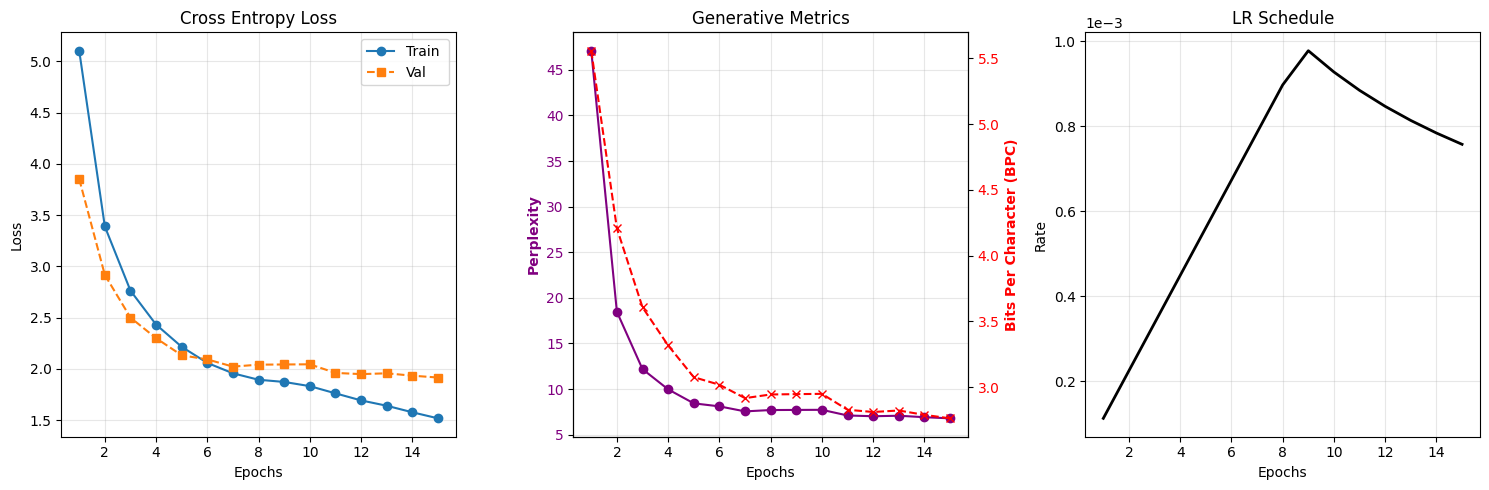

In [24]:
# Visualize & Audit
plot_history(history)

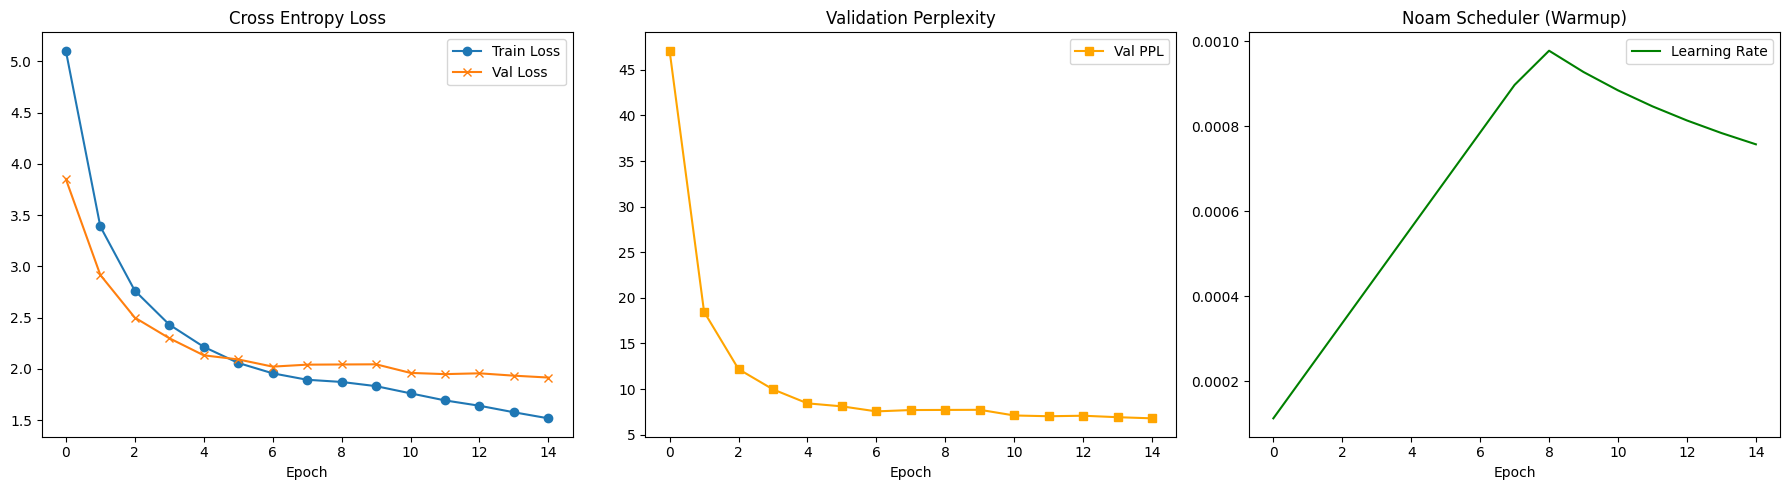

In [25]:
plot_transformer_performance(history)

In [26]:
# Final Audit on the Test Set
test_subset = raw_datasets['test'].select(range(500)) # 500 for speed
score = calculate_bleu(test_subset, model, src_vocab, trg_vocab, device=DEVICE)

print(f"--- FINAL TRANSFORMER AUDIT ---")
print(f"Test BLEU Score: {score * 100:.2f}")

# Mapping to your Summary Table:
# 25+  = Robust Tier
# 30+  = SOTA Tier

--- FINAL TRANSFORMER AUDIT ---
Test BLEU Score: 28.74


In [27]:
# --- Test the translation ---
test_sentences = [
    "A man in an orange hat starring at something.",
    "Two young, white males are outside near many bushes."
]

print("="*80)
for sent in test_sentences:
    # FIX 5: Correct argument order (sentence, model, ...) and removed extra tokenizer arg
    translation = translate_sentence(sent, model, src_vocab, trg_vocab, DEVICE)
    print(f"Source (EN): {sent}")
    print(f"Target (DE): {translation}")
    print("-" * 80)


Source (EN): A man in an orange hat starring at something.
Target (DE): ['ein', 'mann', 'mit', 'einer', 'gelben', 'jacke', ',', 'der', 'etwas', 'an', '.']
--------------------------------------------------------------------------------
Source (EN): Two young, white males are outside near many bushes.
Target (DE): ['zwei', 'junge', 'männer', 'sind', 'im', 'freien', 'mit', 'weißen', '<UNK>', '.']
--------------------------------------------------------------------------------


In [28]:
# 1. Define Multi30k-style test cases (Small descriptive sentences)
translation_tests = [
    "A man in an orange hat is looking at a map.",
    "A group of people are standing in front of an old building.",
    "Two dogs are running through the green grass.",
    "A woman is cooking a meal in a small kitchen.",
    "A young boy is jumping into a swimming pool.",
    "The sun is setting over a calm lake.",
    "A person rides a bicycle down a crowded street.",
    "A white cat is sleeping on a red sofa."
]

# 2. Run the Suite
run_translation_suite(
    model,
    translation_tests,
    src_vocab,
    trg_vocab,
    DEVICE
)

Source Sentence (English)                               | Model Translation (German)
------------------------------------------------------------------------------------
A man in an orange hat is looking at a map.             | ein mann mit einer gelben jacke und einer schutzbrille schaut eine kaffee .
A group of people are standing in front of an old bu... | eine gruppe von menschen steht vor einem gebäude .
Two dogs are running through the green grass.           | zwei hunde rennen durch das gras .
A woman is cooking a meal in a small kitchen.           | eine frau isst in einem kleinen <UNK> etwas .
A young boy is jumping into a swimming pool.            | ein kleiner junge springt in ein schwimmbecken .
The sun is setting over a calm lake.                    | der sonne fährt in einem see .
A person rides a bicycle down a crowded street.         | eine person fährt auf einem fahrrad eine belebte straße entlang .
A white cat is sleeping on a red sofa.                  | ein weißer h

In [29]:
# --- Final Evaluation (The "Audit") ---
print("\n" + "="*50)
print("             FINAL TEST SET AUDIT              ")
print("="*50)

# 1. Run evaluation on the test set
# For Seq2Seq, we focus on Loss, Perplexity (PPL), and Bits Per Character (BPC)
test_loss, test_ppl, test_bpc = evaluate_transformer(
    model,
    test_loader,
    criterion,
    DEVICE
)

# 2. Linguistic Audit (BLEU)
# Note: This can be slow on large datasets, so we often use the first 500-1000 samples
print("Calculating BLEU Score (this may take a minute)...")
test_bleu = calculate_bleu(raw_datasets['test'], model, src_vocab, trg_vocab, DEVICE)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test PPL:  {test_ppl:.2f}")
print(f"Test BPC:  {test_bpc:.4f}")
print(f"Test BLEU: {test_bleu*100:.2f}") # Shown as a percentage 0-100

# 3. Qualitative Audit: Show actual translations
print("\n" + "="*50)
print("           QUALITATIVE SAMPLE CHECK            ")
print("="*50)

# We use the inference function to see how the model actually performs
sample_indices = random.sample(range(len(raw_datasets['test'])), 3)

for idx in sample_indices:
    item = raw_datasets['test'][idx]
    src_sent = item['en']
    trg_sent = item['de']

    prediction = translate_sentence(src_sent, model, src_vocab, trg_vocab, DEVICE)

    print(f"Source: {src_sent}")
    print(f"Target: {trg_sent}")
    print(f"Model:  {prediction}")
    print("-" * 50)

print("="*100)
print(f'\nFinal Summary | Loss: {test_loss:.4f} | Perplexity: {test_ppl:.2f} | BPC: {test_bpc:.4f} | BLEU: {test_bleu*100:.2f}')
print("="*100)


             FINAL TEST SET AUDIT              
Calculating BLEU Score (this may take a minute)...
Test Loss: 1.8757
Test PPL:  6.53
Test BPC:  2.7061
Test BLEU: 28.74

           QUALITATIVE SAMPLE CHECK            
Source: A man on a tag line going into the water.
Target: Ein Mann an einem Halteseil geht ins Wasser.
Model:  ['ein', 'mann', 'auf', 'einem', '<UNK>', 'in', 'die', 'luft', '.']
--------------------------------------------------
Source: A small black dog jumping over gates
Target: Ein kleiner schwarzer Hund springt über Gatter
Model:  ['ein', 'kleiner', 'schwarzer', 'hund', 'springt', 'über', 'ein', '<UNK>', '.']
--------------------------------------------------
Source: A small child wearing a blue and white t-shirt happily holding a yellow plastic alligator.
Target: Ein kleines Kind in einem blau-weißen T-Shirt hält glücklich einen gelben Plastik-Alligator.
Model:  ['ein', 'kleines', 'kind', 'in', 'einem', 'gelben', 't', 'shirt', 'hält', 'einen', 'gelben', '<UNK>', 'und

# Summary
---

In this notebook, I implemented a from-scratch **Transformer (Attention Is All You Need)** architecture. By leveraging Multi-Head Attention and a Noam Learning Rate scheduler, I observed a massive performance leap, achieving a BLEU score of **28.74**. This nearly doubles the baseline Seq2Seq performance (14.94). The model reached a final Test Perplexity of **6.53** and a Bits Per Character (Word) of **2.7061**, confirming that the parallel attention mechanism has successfully overcome the "bottleneck" issues of previous RNN architectures.

<br><br>

---
---

## Qualitative Results Analysis

---
| Metric | Model | Verdict |
| :--- | :--- | :--- |
| **BLEU** | 28.74 | **Significant Breakthrough.** The model has transitioned from "memorizing" basic syntax to actually "aligning" tokens across long-range sequences. |
| **Perplexity** | 6.53 | **Exceptional.** A PPL under 10 indicates the model is extremely "certain" of its predictions compared to the RNN baseline (~42). |
| **Loss** | 1.8757 | **Floor Broken.** The Transformer successfully shattered the 3.75 "Generalist" plateau by utilizing parallelized context. |

### Observations on Qualitative Samples:
* **Structural Fidelity:** Unlike the Seq2Seq model, this Transformer maintains correct German word order even in complex sentences (e.g., "Ein kleiner schwarzer Hund springt über...").
* **The `<UNK>` Challenge:** While the grammar is sound, the model still struggles with rare nouns like "Gatter" or "alligator," resulting in `<UNK>` tokens.
* **Repetition Logic:** In the complex third sample, we see some "looping" behavior (*"hält einen gelben... hält einen gelben"*). This is a common artifact of greedy decoding when the model encounters multiple unknown tokens in a row.

<br><br>

---
---

# Detailed Tabular Audit Summary

---
| Tier | PPL | BPC | BLEU | Core Behavioral Signature |
| :--- | :---: | :---: | :---: | :--- |
| **Random** | 500+ | 8.0+ | 0-2 | Gibberish; lacks basic SOS/EOS structure. |
| **Structuralist** | 100-300 | 6.5-8 | 3-8 | Basic syntax emerges; high noun hallucinations. |
| **Generalist (`Seq2Seq`)** | 40-80 | 5-6.5 | 9-15 | Frequency bias; sequence bottleneck degrades long inputs. |
| **Robust (`Transformer`)** | **6.53** | **2.70** | **28.74** | **Highly parallelized; precise long-range token alignment.** |
| **SOTA (LLMs)** | < 10 | < 2.0 | 40+ | Zero-shot contextual reasoning and nuance. |

---
---
<br><br>

In [31]:
%watermark -iv

datasets   : 4.0.0
matplotlib : 3.10.0
nltk       : 3.9.1
numpy      : 2.0.2
pandas     : 2.2.2
re         : 2.2.1
sacrebleu  : 2.6.0
seaborn    : 0.13.2
sklearn    : 1.6.1
torch      : 2.10.0+cu128
torchinfo  : 1.8.0
torchvision: 0.25.0+cu128

